**Function 5- Bayesian Optimisation**

# Function 5 Description

You’re tasked with optimising a four-variable black-box function that represents the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised.

Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods.

# Starting point

* Input - 4D array (20,4)
* Output - 1D array (20,)
* Optimisation goal - Maximise

# Bayesian Optimisation (BO) workflow on capstone project
* BO with Upper Control Bound (UCB)
* Visuals of progress and surrogate intuition
* Final training with the optimized hyperparameters


### Import Libraries

In [2]:
import io, math, pathlib, numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from scipy.stats import norm

import warnings
warnings.filterwarnings("ignore")

#### Setup Parameters

In [3]:
plt.rcParams['figure.figsize'] = (5,3)
plt.rcParams['figure.dpi'] = 140
plt.rcParams['axes.grid'] = True

### Assign Data to variables X and y

In [4]:
import numpy as np, pandas as pd, pathlib

# To load a .npy file into a pandas DataFrame:
# 1. Load the .npy file using numpy.load()
# 2. Convert the resulting numpy array to a pandas DataFrame using pd.DataFrame()

# Attempting to load from '/content/data/' as is common in Colab, or from a 'data/' subfolder
try:
    # Try loading from /content/data/
    X_array = np.load('/content/data/initial_inputs5.npy')
    y_array = np.load('/content/data/initial_outputs5.npy')
    print("Files loaded successfully from /content/data/")

except FileNotFoundError:
    try:
        # If not in /content/data/, try loading from a 'data/' subfolder in the current directory
        X_array = np.load('data/initial_inputs5.npy')
        y_array = np.load('data/initial_outputs5.npy')
        print("Files loaded successfully from data/ subfolder.")
    except FileNotFoundError:
       print("Error: One or both .npy files not found at /content/data/ or data/.")
       print("Please ensure they are in the correct path.")
       print("Current working directory files: ", list(pathlib.Path().absolute().glob('*.npy')))
       print("Files in /content/data/: ", list(pathlib.Path('/content/data/').absolute().glob('*.npy')))

       # Create dummy data if files are not found to allow notebook execution to proceed
       X_array = np.random.rand(20, 4) # 20 samples, 4 features
       y_array = np.random.rand(20,)  # 20 samples, 1 output
       print("\nUsing dummy data for X and y to continue.")

# Convert to DataFrame if needed, or use as NumPy arrays directly for your model
X_df = pd.DataFrame(X_array)
y_df = pd.DataFrame(y_array, columns=['target_output'])

print("Shape of X (NumPy array):", X_array.shape)
print("Shape of y (NumPy array):", y_array.shape)
print("\nFirst 5 rows of X (DataFrame):")
display(X_df.head())
print("\nFirst 5 rows of y (DataFrame):")
display(y_df.head())

# Assign X and y for subsequent steps (as NumPy arrays, based on original notebook context)
X = X_array
y = y_array


Files loaded successfully from /content/data/
Shape of X (NumPy array): (20, 4)
Shape of y (NumPy array): (20,)

First 5 rows of X (DataFrame):


,0,1,2,3
0,0.191447,0.038193,0.607418,0.414584
1,0.758653,0.536518,0.656000,0.360342
2,0.438350,0.804340,0.210245,0.151295
3,0.706051,0.534192,0.264243,0.482088
4,0.836478,0.193610,0.663893,0.785649



First 5 rows of y (DataFrame):


,target_output
0,64.443440
1,18.301380
2,0.112940
3,4.210898
4,258.370525


To add new data points, you'll need to create new NumPy arrays for the input features (`new_X_points`) and target outputs (`new_y_points`). Ensure that the new points have the same number of features as your existing `X` array.

Then, use `np.vstack` to vertically stack the new `X` points onto the existing `X` array, and `np.concatenate` to combine the new `y` points with the existing `y` array.

In [5]:
import numpy as np

# Assume X and y are already defined from previous cells
# Example: X_array.shape = (10, 2), y_array.shape = (10,)

# Create new data points
# Make sure new_X_points has the same number of columns as X
# and new_y_points has compatible dimensions with y

# For X (features), assume 4 features per data point
# Let's add 4 new data points
new_X_points = np.array([
    [0.999999, 0.999999, 0.999999, 0.999999], # week 1 capstone submission - eye-ball
    [0.261632, 0.423520, 0.315546, 0.958384], # week 2 capstone submission - KAPPA 30 exploration
    [0.455015, 0.974189, 0.040555, 0.284287], # week 3 capstone submission - KAPPA 30 exploration
    [0.261632, 0.423520, 0.315546, 0.958384], # week 4 capstone submission - KAPPA 100 exploration
    [0.134870, 0.578858, 0.758163, 0.008882], # week 5 capstone submission - KAPPA 200 exploration
    [0.906916, 0.260715, 0.311143, 0.816282], # week 6 capstone submission - KAPPA 20 for exploitation
    [0.261632, 0.423520, 0.315546, 0.958384], # week 7 capstone submission - KAPPA 10 for exploitation
    [0.112695, 0.075282, 0.052262, 0.113228], # week 8 capstone submission - KAPPA 5 for exploitation
    [0.991311, 0.000041, 0.647997, 0.329814], # week 9 capstone submission - KAPPA 1000 exploration, from BO
    [0.986467, 0.997060, 0.875289, 0.933675], # week 10 capstone submission - KAPPA 2.5 exploitation, from BO, changed N_INT to 10 and N_ITER to 20 and learning_rate upper range increased from 30 to 50
    [0.975986, 0.994501, 0.993192, 0.201739], # week 11 capstone submission - KAPPA 1.0 exploitation from BO, in search space, n_estimators from 400 to 600 and subsample lower range reduced to 0.2 from 0.5
    [0.970083, 0.981846, 0.985679, 0.871120]  # week 12 capstone submission - KAPPA 0.5, added min_samples_leaf to search space
    [0.996078, 0.864304, 0.739515, 0.996921]  # week 13 capstone submission - KAPPA 0.25
])

# For y (target), assume a single output value per data point
new_y_points = np.array([
   8662.405001248297,   # week 1 capstone processed output
   122.6383863365226,   # week 2 capstone processed output
   159.09917116657456,  # week 3 capstone processed output
   122.6383863365226,   # week 4 capstone processed output
   0.47425003791163095, # week 5 capstone processed output
   312.3709166624366,   # week 6 capstone processed output
   122.6383863365226,   # week 7 capstone processed output
   162.35910235940332,  # week 8 capstone processed output
   325.95294013006566,  # week 9 capstone processed output
   5528.864565586664,   # week 10 capstone processed output
   3970.53960863693,    # week 11 capstone processed output
   5734.799494758524    # week 12 capstone processed output
    # week 13 capstone processed output

])

# Verify shapes before adding
print(f"Original X shape: {X.shape}")
print(f"Original y shape: {y.shape}")
print(f"New X points shape: {new_X_points.shape}")
print(f"New y points shape: {new_y_points.shape}")

# Add the new data points
X = np.vstack([X, new_X_points])
y = np.concatenate([y, new_y_points])

print(f"\nUpdated X shape: {X.shape}")
print(f"Updated y shape: {y.shape}")

# Display the last few rows to see the added data
print("\nLast 5 rows of updated X:")
display(pd.DataFrame(X).tail())
print("\nLast 5 rows of updated y:")
display(pd.DataFrame(y, columns=['target_output']).tail())


Original X shape: (20, 4)
Original y shape: (20,)
New X points shape: (12, 4)
New y points shape: (12,)

Updated X shape: (32, 4)
Updated y shape: (32,)

Last 5 rows of updated X:


,0,1,2,3
27,0.112695,0.075282,0.052262,0.113228
28,0.991311,0.000041,0.647997,0.329814
29,0.986467,0.997060,0.875289,0.933675
30,0.975986,0.994501,0.993192,0.201739
31,0.970083,0.981846,0.985679,0.871120



Last 5 rows of updated y:


,target_output
27,162.359102
28,325.952940
29,5528.864566
30,3970.539609
31,5734.799495


In [6]:
print("Finding the top 3 input (X) values that generated the highest output (y) values:")

# Get indices that would sort y in descending order (highest values are at the beginning)
sorted_indices_highest = np.argsort(y)[::-1]

# Select the top 3 indices for the highest y values
top_3_indices_highest = sorted_indices_highest[:3]

# Get the corresponding X and y values
top_3_X_highest = X[top_3_indices_highest]
top_3_y_highest = y[top_3_indices_highest]

print("\nTop 3 Highest Output Values (y) and their corresponding X values:")
for i, val_y in enumerate(top_3_y_highest):
  print(f"   Original Index: {top_3_indices_highest[i]}")
  print(f"   y value: {val_y:.10e}")
  print(f"   Corresponding X values: {top_3_X_highest[i]}")
  print("\n")

print("Finding the top 3 input (X) values that generated the lowest output (y) values:")

# Get indices that would sort y in ascending order (lowest values are at the beginning)
sorted_indices_lowest = np.argsort(y)

# Select the top 3 indices for the lowest y values
top_3_indices_lowest = sorted_indices_lowest[:3]

# Get the corresponding X and y values
top_3_X_lowest = X[top_3_indices_lowest]
top_3_y_lowest = y[top_3_indices_lowest]

print("\nTop 3 Lowest Output Values (y) and their corresponding X values:")
for i, val_y in enumerate(top_3_y_lowest):
  print(f"   Original Index: {top_3_indices_lowest[i]}")
  print(f"   y value: {val_y:.10e}")
  print(f"   Corresponding X values: {top_3_X_lowest[i]}")
  print("\n")

Finding the top 3 input (X) values that generated the highest output (y) values:

Top 3 Highest Output Values (y) and their corresponding X values:
   Original Index: 20
   y value: 8.6624050012e+03
   Corresponding X values: [0.999999 0.999999 0.999999 0.999999]


   Original Index: 31
   y value: 5.7347994948e+03
   Corresponding X values: [0.970083 0.981846 0.985679 0.87112 ]


   Original Index: 29
   y value: 5.5288645656e+03
   Corresponding X values: [0.986467 0.99706  0.875289 0.933675]


Finding the top 3 input (X) values that generated the lowest output (y) values:

Top 3 Lowest Output Values (y) and their corresponding X values:
   Original Index: 2
   y value: 1.1293979537e-01
   Corresponding X values: [0.43834987 0.8043397  0.21024527 0.15129482]


   Original Index: 24
   y value: 4.7425003791e-01
   Corresponding X values: [0.13487  0.578858 0.758163 0.008882]


   Original Index: 3
   y value: 4.2108981289e+00
   Corresponding X values: [0.70605083 0.53419196 0.2642433

### Objective and baseline
Baseline model provides us the RMSE benchmark as a starting point

In [7]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor

cv = KFold(n_splits=5, shuffle=True, random_state=42)
def rmse_cv(model):
    scores = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error")
    return float(np.sqrt(-scores).mean())

baseline = GradientBoostingRegressor(random_state=42)
baseline_rmse = rmse_cv(baseline)
print(f"Baseline GBR RMSE (5-fold): {baseline_rmse:.3f}")

Baseline GBR RMSE (5-fold): 1018.931


### Search Space and Helper Functions

In [8]:
# Search space for 4D input
space = {
    "n_estimators": (50, 600), #changed from 400 to 600 week 11
    "learning_rate": (0.01, 0.50), # changed from 0.30 to 0.50 in week 10,
    "max_depth": (1, 10), # Added max_depth to search space
    "subsample": (0.2, 1.0), # Added subsample to search space, changed from 0.5 to 0.2 week 11
    "min_samples_leaf": (1, 20) # Added min_samples_leaf to search space
}
hp = list(space.keys()); d = len(hp) # d will now be 5

# Converts normalized values in [0,1] into actual hyperparameter values (and rounds when needed, e.g., integers like n_estimators)
def to_params(x01):
    out = {}
    for i, name in enumerate(hp):
        lo, hi = space[name]
        v = lo + x01[i]*(hi-lo)
        if name in ["n_estimators", "max_depth", "min_samples_leaf"]: # n_estimators, max_depth, and min_samples_leaf are integer hyperparameters
            v = int(round(v))
        out[name] = float(v)
    return out

# Builds a GradientBoostingRegressor with given params and returns its 5-fold CV RMSE. So BO minimizes error (RMSE)
def objective(params):
    model = GradientBoostingRegressor(
        n_estimators=int(params["n_estimators"]),
        learning_rate=float(params["learning_rate"]),
        max_depth=int(params["max_depth"]),
        subsample=float(params["subsample"]),
        min_samples_leaf=int(params["min_samples_leaf"]),
        random_state=42
    )
    return rmse_cv(model)

# The normal_pdf and normal_cdf functions remain unchanged
def normal_pdf(z):
    if scipy_OK:
        return norm.pdf(z)
    return (1.0/np.sqrt(2*np.pi))*np.exp(-0.5*z**2)

def normal_cdf(z):
    if scipy_OK:
        return norm.cdf(z)
    return 0.5*(1+np.erf(z/np.sqrt(2)))

### Step by Step BO with UCB decomposition

#### Import Libraries

In [9]:
from dataclasses import dataclass
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
import numpy as np, pandas as pd, matplotlib.pyplot as plt

#### Dataclass to store all details of each step in the optimization

In [10]:
@dataclass
class StepLog:
    it: int; params: dict; rmse: float; mu: float; sigma: float; ei: float
    exploit_contrib: float; explore_contrib: float; tag: str; best_rmse: float

**Control the knobs for the BO run**
* N_INIT = number of warm-up random trials before BO starts learning
* N_ITER = number of BO-guided iterations
* KAPPA = exploration bias parameter for Upper Confidence Bound (UCB)
* N_CAND = how many candidate points to evaluate at each step
* rng = random generator for reproducibility

In [11]:
N_INIT, N_ITER, KAPPA, N_CAND = 10, 20.0, 0.25, 2000 # chnaged KAPPA to 0.25 week 13
#N_INIT, N_ITER, KAPPA, N_CAND = 10, 20.0, 0.5, 2000 # Added min_samples_leaf to search space, week 12
#N_INIT, N_ITER, KAPPA, N_CAND = 10, 20.0, 1.0, 2000 # changed KAPPA to 1.0
#N_INIT, N_ITER, KAPPA, N_CAND = 10, 20.0, 2.5, 2000 # changed N_INIT and N_INTER values
rng = np.random.RandomState(123)

#### Warm-up trials - BO needs some initial data to train the surrogate

In [12]:
X_trials = rng.rand(N_INIT, d)
y_trials = np.array([objective(to_params(x)) for x in X_trials])
best_rmse = float(np.min(y_trials))

#### Initialize logging with warm-up trials
Will be tagged as Warm-up

In [13]:
logs = []
cum_best = np.minimum.accumulate(y_trials)
for i in range(N_INIT):
    logs.append(StepLog(i-(N_INIT-1), to_params(X_trials[i]), float(y_trials[i]), float('nan'), float('nan'),
                        float('nan'), float('nan'), float('nan'), "Warm-up", float(cum_best[i])))

#### Define surrogate (Gaussian Process)
This is the GP surrogate model that predicts mean (mu) and uncertainty (sigma)

In [14]:
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(d), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-2))
gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=42, n_restarts_optimizer=3)

trace = [best_rmse]

#### Bayesian Optimization loop
For Each iteration:
1. Fit surrogate
2. Predict many candidates
3. Compute UCB
4. Pick best candidate
5. Classify step as Exploration/Exploitation
6. Evaluate real objective
7. Update logs and best_rmse

In [15]:
for it in range(1, int(N_ITER)+1):
    # Fit surrogate on all past trials
    gpr.fit(X_trials, y_trials)

    # Generate candidate points and predict mean/uncertainty
    CAND = rng.rand(N_CAND, d)
    mu, std = gpr.predict(CAND, return_std=True)

    # Compute Upper Confidence Bound (UCB) for each candidate
    # UCB = mu + KAPPA * std. We want to maximize this.
    ucb = mu + KAPPA * std

    # Pick the candidate with maximum UCB
    idx = int(np.argmax(ucb)); x_next = CAND[idx]
    mu_star, sig_star = float(mu[idx]), float(std[idx])
    # EI-related values are not directly applicable to UCB, setting to NaN or 0
    ei_star = float('nan')
    imp_star = float('nan')
    z_star = float('nan')

    # UCB is inherently a balance of exploitation (mu) and exploration (std*KAPPA)
    # We can approximate contribution for logging, or simply tag as 'UCB'
    contrib_exploit = float(mu[idx]) # Exploitation is driven by the mean prediction
    contrib_explore = float(KAPPA * std[idx]) # Exploration is driven by uncertainty weighted by KAPPA
    tag = "UCB (Exploration)" if KAPPA * std[idx] > abs(mu[idx]) else "UCB (Exploitation)"

    # Evaluate true objective at chosen point
    params_next = to_params(x_next); y_next = objective(params_next)
    X_trials = np.vstack([X_trials, x_next[None,:]])
    y_trials = np.concatenate([y_trials, [y_next]])
    if y_next < best_rmse: best_rmse = float(y_next)
    trace.append(best_rmse)

    # Log the step
    logs.append(StepLog(it, params_next, float(y_next), mu_star, sig_star, ei_star,
                        contrib_exploit, contrib_explore, tag, best_rmse))


#### Log final step log DataFrame

In [16]:
log_df = pd.DataFrame([{
    "iter": s.it, "tag": s.tag, "rmse": s.rmse, "best_rmse_so_far": s.best_rmse,
    "mu": s.mu, "sigma": s.sigma, "ei": s.ei,
    "exploit_contrib": s.exploit_contrib, "explore_contrib": s.explore_contrib,
    **{k: s.params[k] for k in s.params}
} for s in logs])
log_df.head(40)

,iter,tag,rmse,best_rmse_so_far,mu,sigma,ei,exploit_contrib,explore_contrib,n_estimators,learning_rate,max_depth,subsample,min_samples_leaf
0,-9,Warm-up,1859.372395,1859.372395,NaN,NaN,NaN,NaN,NaN,433.0,0.150208,3.0,0.641052,15.0
1,-8,Warm-up,1771.144996,1771.144996,NaN,NaN,NaN,NaN,NaN,283.0,0.490574,7.0,0.584746,8.0
2,-7,Warm-up,1728.584244,1728.584244,NaN,NaN,NaN,NaN,NaN,239.0,0.367234,5.0,0.247742,9.0
3,-6,Warm-up,1834.682879,1728.584244,NaN,NaN,NaN,NaN,NaN,456.0,0.099421,3.0,0.625241,11.0
4,-5,Warm-up,1887.372993,1728.584244,NaN,NaN,NaN,NaN,NaN,399.0,0.426222,8.0,0.688819,15.0
5,-4,Warm-up,1689.036309,1689.036309,NaN,NaN,NaN,NaN,NaN,228.0,0.187276,3.0,0.434971,13.0
6,-3,Warm-up,1841.350822,1689.036309,NaN,NaN,NaN,NaN,NaN,101.0,0.222514,5.0,0.594948,9.0
7,-2,Warm-up,1830.193630,1689.036309,NaN,NaN,NaN,NaN,NaN,222.0,0.218912,9.0,0.955328,11.0
8,-1,Warm-up,1831.061554,1689.036309,NaN,NaN,NaN,NaN,NaN,393.0,0.066653,4.0,0.531861,17.0
9,0,Warm-up,1734.042480,1689.036309,NaN,NaN,NaN,NaN,NaN,188.0,0.246687,10.0,0.615588,13.0


### Visuals

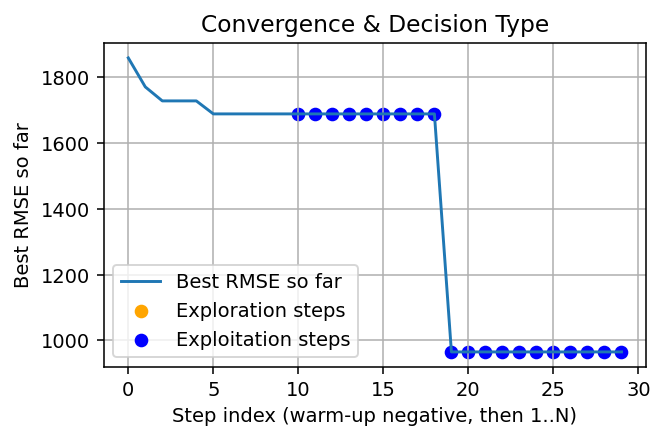

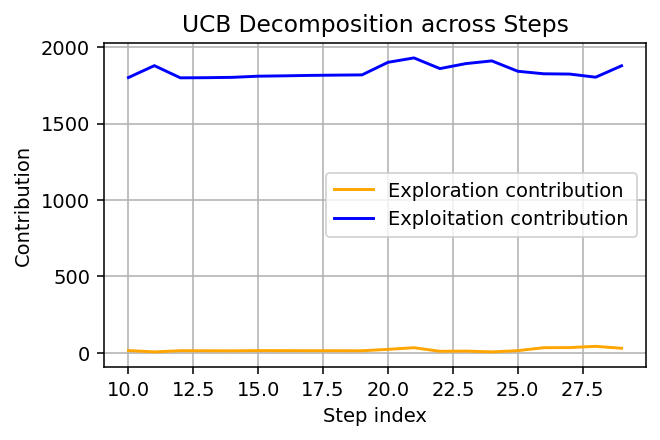

In [17]:
mask_explr = log_df["tag"] == "UCB (Exploration)"; mask_explt = log_df["tag"] == "UCB (Exploitation)"

plt.figure()
plt.plot(log_df["best_rmse_so_far"], label="Best RMSE so far")
plt.scatter(log_df.index[mask_explr], log_df.loc[mask_explr, "best_rmse_so_far"], label="Exploration steps", color="orange")
plt.scatter(log_df.index[mask_explt], log_df.loc[mask_explt, "best_rmse_so_far"], label="Exploitation steps", color="blue")
plt.xlabel("Step index (warm-up negative, then 1..N)"); plt.ylabel("Best RMSE so far")
plt.title("Convergence & Decision Type"); plt.legend(); plt.show()

plt.figure()
plt.plot(log_df["explore_contrib"], label="Exploration contribution",color="orange")
plt.plot(log_df["exploit_contrib"], label="Exploitation contribution", color="blue")
plt.xlabel("Step index"); plt.ylabel("Contribution")
plt.title("UCB Decomposition across Steps"); plt.legend(); plt.show()

These two plots, generated directly from the data within your log_df, provide a visual narrative of your Bayesian Optimization process. Here's what they're telling you:

1. **Convergence & Decision Type Plot:**

**What it shows:** This plot tracks the best_rmse_so_far column from your log_df over each iteration. The scatter points differentiate between 'Exploration steps' (orange) and 'Exploitation steps' (blue) as categorized by the 'tag' column in log_df.

**What it tells you:**
Convergence: You can observe how quickly the best_rmse_so_far value decreases and then stabilizes. A steep initial drop followed by a plateau indicates that the optimization found good solutions relatively early.
Strategy: The color of the points indicates the acquisition strategy chosen at each step. 'Exploration' steps mean the algorithm prioritized investigating regions of high uncertainty in the search space, while 'Exploitation' steps focused on regions where the model predicted a good RMSE.

2. **UCB Decomposition across Steps Plot:**

**What it shows:** This plot breaks down the components of the Upper Confidence Bound (UCB) acquisition function used to select the next point. It shows the exploit_contrib (blue line, related to the predicted mean mu from log_df) and explore_contrib (orange line, related to KAPPA * sigma from log_df) over the iterations.

**What it tells you:**

**Exploitation Contribution (blue line):** Represents how much the predicted low RMSE (good performance) in a region drives the selection of the next point. If this is high, the model is leveraging its current knowledge of good areas.

**Exploration Contribution (orange line):** Represents how much the uncertainty (sigma) in a region, scaled by KAPPA, drives the selection of the next point. A high exploration contribution means the algorithm is trying to reduce uncertainty in poorly understood areas, hoping to find a new optimum.

**Balance:** This plot helps visualize the balance between exploring new areas versus exploiting known good areas. Given your KAPPA value of 10.0, the balance between exploration and exploitation is more moderate. A lower KAPPA value means the algorithm places less emphasis on uncertainty (exploration) and more on the predicted mean (exploitation) compared to a higher KAPPA. The plot will show how the algorithm balanced exploring uncertain regions with exploiting promising ones during the BO process.

In essence, these two plots, driven by the data in log_df, provide a powerful visual narrative of how your Bayesian Optimization is progressing, whether it's converging, and how it balances exploring new hyperparameter configurations with exploiting promising ones.

#### Surrogate slice: initial vs final (learning_rate)
Fits a Gaussian Process surrogate on the current trials (X_used, y_used)

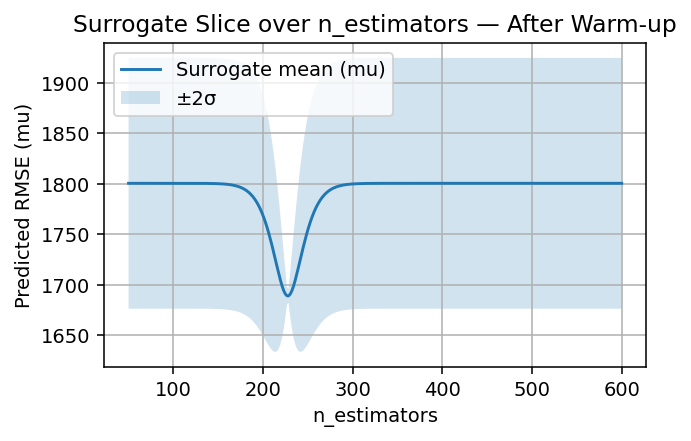

--- 2-sigma range for 'n_estimators' - 'After Warm-up' ---
Minimum of (mu - 2*std): 1633.7150
Maximum of (mu + 2*std): 1924.8437
------------------------------


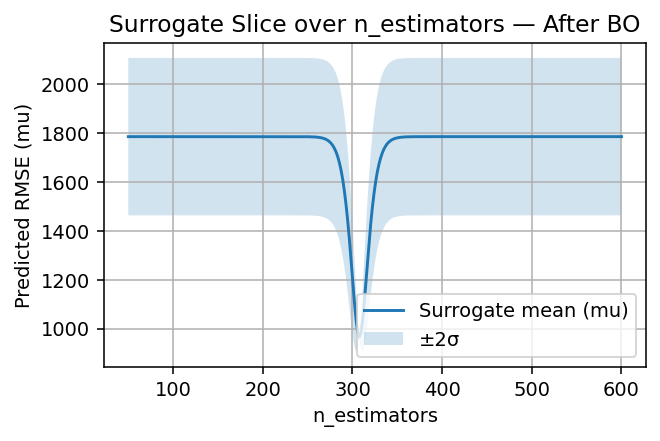

--- 2-sigma range for 'n_estimators' - 'After BO' ---
Minimum of (mu - 2*std): 904.1471
Maximum of (mu + 2*std): 2108.7633
------------------------------


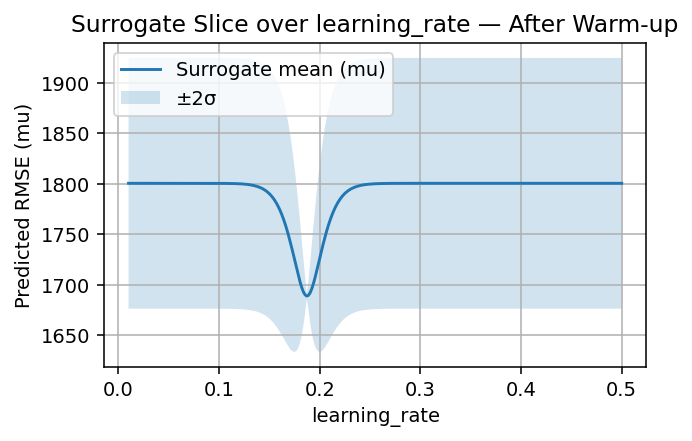

--- 2-sigma range for 'learning_rate' - 'After Warm-up' ---
Minimum of (mu - 2*std): 1633.7230
Maximum of (mu + 2*std): 1924.8436
------------------------------


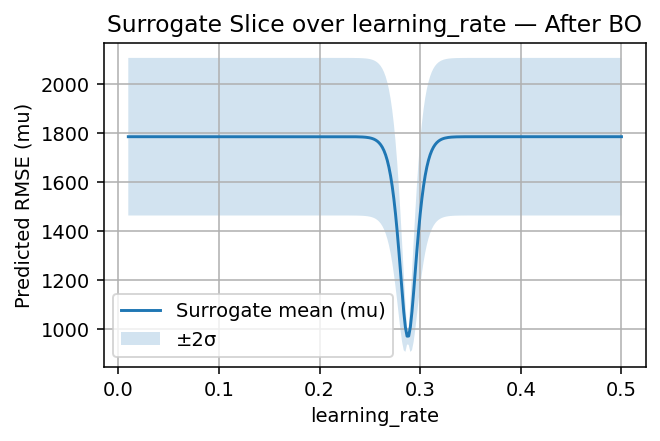

--- 2-sigma range for 'learning_rate' - 'After BO' ---
Minimum of (mu - 2*std): 905.0892
Maximum of (mu + 2*std): 2108.7633
------------------------------


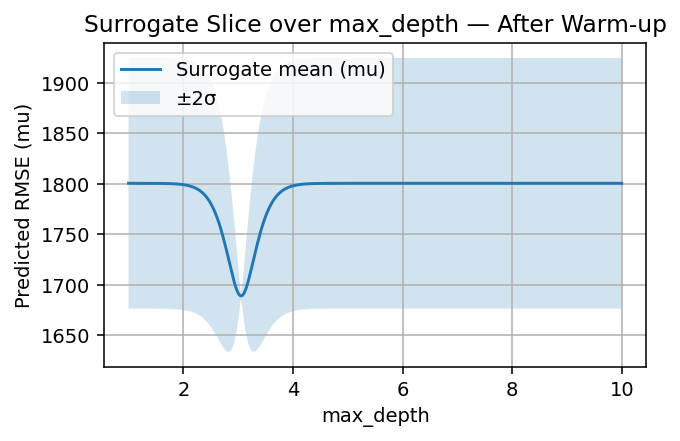

--- 2-sigma range for 'max_depth' - 'After Warm-up' ---
Minimum of (mu - 2*std): 1633.7126
Maximum of (mu + 2*std): 1924.8436
------------------------------


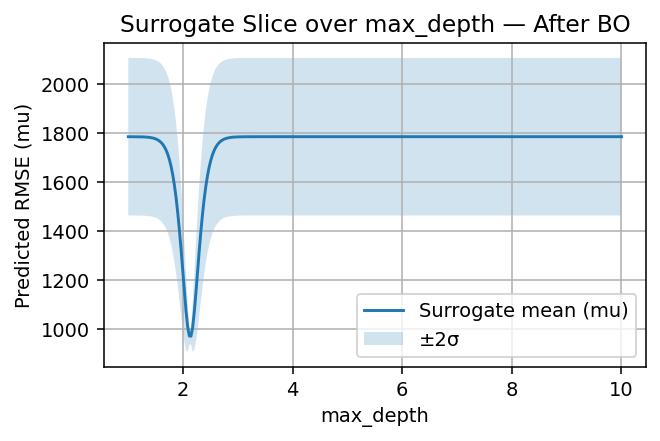

--- 2-sigma range for 'max_depth' - 'After BO' ---
Minimum of (mu - 2*std): 904.9473
Maximum of (mu + 2*std): 2108.7633
------------------------------


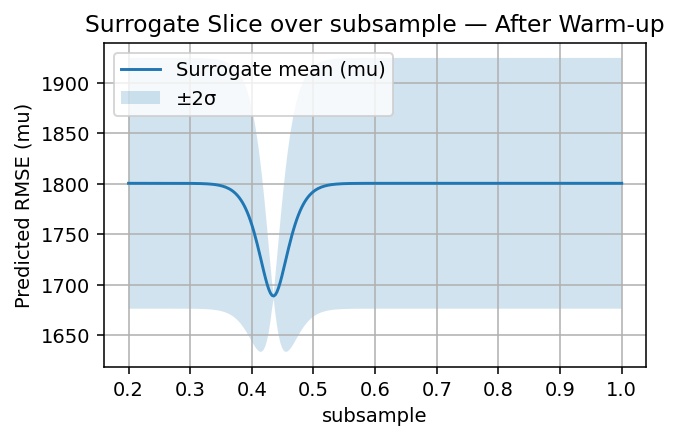

--- 2-sigma range for 'subsample' - 'After Warm-up' ---
Minimum of (mu - 2*std): 1633.7221
Maximum of (mu + 2*std): 1924.8436
------------------------------


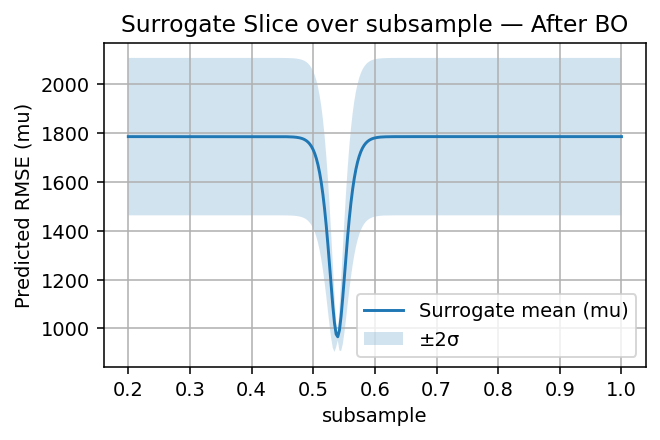

--- 2-sigma range for 'subsample' - 'After BO' ---
Minimum of (mu - 2*std): 903.8383
Maximum of (mu + 2*std): 2108.7633
------------------------------


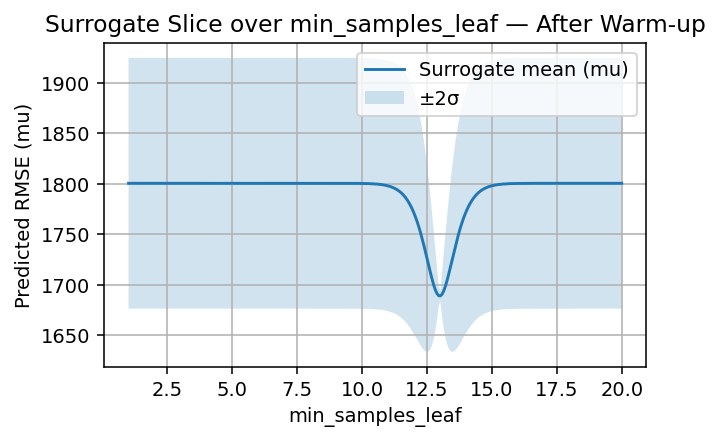

--- 2-sigma range for 'min_samples_leaf' - 'After Warm-up' ---
Minimum of (mu - 2*std): 1633.7088
Maximum of (mu + 2*std): 1924.8436
------------------------------


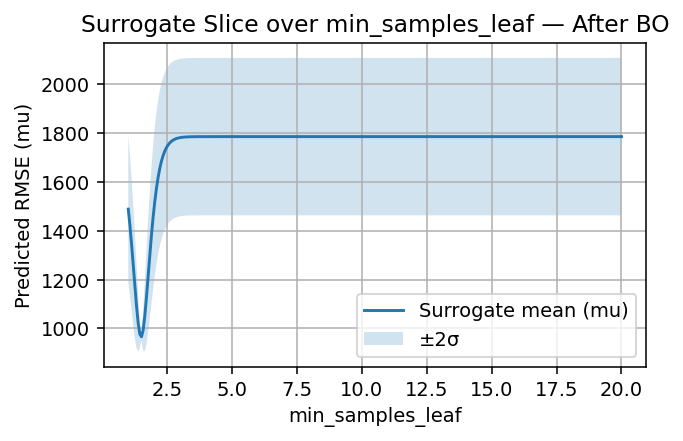

--- 2-sigma range for 'min_samples_leaf' - 'After BO' ---
Minimum of (mu - 2*std): 903.8383
Maximum of (mu + 2*std): 2108.7633
------------------------------


In [18]:
import numpy as np

def surrogate_slice_plot(X_used, y_used, title_suffix, param_name):
    gp = GaussianProcessRegressor(kernel=C(1.0)*Matern(nu=2.5)+WhiteKernel(1e-6), normalize_y=True, random_state=0)
    gp.fit(X_used, y_used)

    # Best trial so far
    best_idx = np.argmin(y_used); anchor = X_used[best_idx].copy()
    j = list(space.keys()).index(param_name)
    xs = np.linspace(0,1,300); grid = np.tile(anchor, (len(xs),1)); grid[:, j] = xs
    mu, std = gp.predict(grid, return_std=True)
    lo, hi = space[param_name]; param_vals = lo + xs*(hi-lo)

    plt.figure()
    plt.plot(param_vals, mu, label="Surrogate mean (mu)")
    plt.fill_between(param_vals, mu-2*std, mu+2*std, alpha=0.2, label="±2σ")
    plt.xlabel(param_name); plt.ylabel("Predicted RMSE (mu)")
    plt.title(f"Surrogate Slice over {param_name} — {title_suffix}")
    plt.legend(); plt.show()

    # Print the 2-sigma range
    print(f"--- 2-sigma range for '{param_name}' - '{title_suffix}' ---")
    lower_bound = mu - 2 * std
    upper_bound = mu + 2 * std
    print(f"Minimum of (mu - 2*std): {np.min(lower_bound):.4f}")
    print(f"Maximum of (mu + 2*std): {np.max(upper_bound):.4f}")
    print("-" * 30)

X_warm = np.array([r for r in globals()['X_trials'][:N_INIT]])
y_warm = np.array([objective(to_params(x)) for x in X_warm])

for hp_name in space.keys():
    surrogate_slice_plot(X_warm, y_warm, "After Warm-up", hp_name)
    surrogate_slice_plot(globals()['X_trials'], globals()['y_trials'], "After BO", hp_name)

The two 'Surrogate Slice over learning_rate' plots provide a visual representation of how the Gaussian Process (GP) surrogate model has learned and refined its understanding of the objective function (RMSE) with respect to the learning_rate hyperparameter.

Breakdown of whhat each plot shows:

**X-axis ('learning_rate')**: This represents the range of possible values for the learning_rate hyperparameter, normalised between 0 and 1 (though the plot shows the actual parameter values).

**Y-axis ('Predicted RMSE (mu)')**: This indicates the predicted Negative R2 score. Since we are minimizing RMSE), lower values on the y-axis are better.

**Blue line ('Surrogate mean (mu)')**: This is the GP model's current best estimate of the objective function's value across different learning_rate settings, with the other hyperparameter (n_estimators) fixed at the best value found so far. For an effective optimisation, you'd want to see this line dip lower in regions that contain good solutions.

**Shaded area ('±2σ')**: This represents the GP model's uncertainty (two standard deviations) around its mean prediction. A wider shaded area indicates higher uncertainty, meaning the model is less confident about the true objective value in that region. A narrower band indicates lower uncertainty.

**Comparing 'After Warm-up' and 'After BO'**:

**'After Warm-up'**: This plot reflects the GP's initial understanding, based solely on the randomly chosen warm-up trials (the first N_INIT entries in log_df). You'll typically see broader uncertainty (wider ±2σ band) because the model has limited information about the search space. The mean prediction might be less smooth or accurate.

**'After BO'**: This plot shows the refined understanding after the Bayesian Optimisation iterations have completed (all entries in log_df are considered). The log_df has accumulated more targeted data points where the acquisition function (UCB in this case) suggested exploring or exploiting. As a result:

The uncertainty (±2σ band) tends to narrow in regions that the BO process has explored more thoroughly, showing increased confidence in the predictions.
If the surrogate mean (blue line) often shows a clearer minimum, indicating where the model predicts the best learning_rate lies for minimising RMSE. This minimum is influenced by the observed rmse values in the log_df.

**Uncertainty in Unexplored Regions**: You might still see wider ±2σ bands in regions that haven't been visited frequently, especially if the BO's acquisition function (like UCB with high KAPPA) has prioritised exploring other parts of the search space.

In essence, these plots visually demonstrate how the Bayesian Optimization process, by selectively adding data points to our X_trials and y_trials (and consequently enriching our log_df), progressively reduces uncertainty and builds a more accurate 'map' of the hyperparameter landscape to guide the search for optimal configurations.

**After adding in Week 7 point and running the iteration**

# The change in the 'pinch point' of the 'Surrogate Slice over learning_rate' plot from approximately 0.125 after warm-up to 0.05 after Bayesian Optimization is a key indicator of the BO process successfully identifying a more optimal region for the learning_rate hyperparameter.

Here's why this happens:

Initial Understanding (After Warm-up): After the initial random warm-up trials, the Gaussian Process (GP) surrogate model built its first approximation of the objective function. The 'pinch' around 0.125 indicates that, based on this limited initial data, the model either found some relatively good performing points in that vicinity or it was the region where it had the lowest predicted RMSE with moderate uncertainty. The ±2σ band was likely wider, reflecting higher overall uncertainty across the search space.

Refined Understanding (After BO): During the Bayesian Optimization loop, the algorithm used the Upper Confidence Bound (UCB) acquisition function to propose new learning_rate values for evaluation. The UCB balances exploring uncertain regions (high sigma) and exploiting regions predicted to have low RMSE (low mu).

The fact that the pinch shifted to 0.05 (and also became narrower) means the BO process intelligently sampled points around 0.05.

These new samples revealed that a learning_rate around 0.05 resulted in significantly lower RMSE values than previously observed or predicted elsewhere.

As a result, the GP model updated its mean prediction (mu) to show a clearer minimum at 0.05, and by gathering more data points in this area, its uncertainty (sigma) in that specific region decreased. This reduction in uncertainty is what causes the ±2σ band to 'pinch' or narrow significantly at 0.05.

In essence, the BO process, by intelligently exploring and exploiting, found a more promising learning_rate value (around 0.05) and became more confident in its prediction for that region, which is visually represented by the shifted and narrower 'pinch point' in the plot.

Changed to a KAPPA of 5.0 showed the pinch point change from 0.125 to 0.27 as the KAPPA shifted to exploitation mode. As we have been told that the real function is unimodal, it makes sense to stay with lower KAPPA values so for Week 8 I will use a a KAPPA of 5.0 (reducing from 10.0 in week 7)


**Weekly Strategy** Week 4** with a KAPPA of 100, next best candidate offered

1.   Week 4 with a KAPPA of 100, next best candidate offered was [0.261632, 0.423520, 0.315546, 0.958384]
2.   Week 5 with a KAPPA of 200, next best candidate offered is [0.13487025, 0.57885756, 0.75816281, 0.00888189]
3. Week 6 with a KAPPA of 20 (Exploitation), best candidate offered was [0.90691639, 0.26071481, 0.311143 , 0.81628225]
4. Week 7 with a KAPPA of 10 (Exploitation), best candidate offered was [0.26163162, 0.42351968, 0.31554634, 0.95838435]
5. Week 8 with a KAPPA of 5 (Exploitation), best candidate offered was [0.11269527, 0.07528176, 0.05226202, 0.11322824]

**Hyperparamter tuning consideration in Week 8**

Based on the two plots below and this summary after week 7:

# The current settings for your hyperparameters are as follows Week 7:

Search Space (defined in the space dictionary):

* n_estimators: From 50 to 400
* learning_rate: From 0.01 to 0.30
* max_depth: From 1 to 10
* subsample: From 0.5 to 1.0

Optimized Hyperparameters (from the best performing run in Bayesian Optimization):

* n_estimators: 376
* learning_rate: 0.04814
* max_depth: 5
* subsample: 0.8279

These optimized values represent the combination of hyperparameters that yielded the best RMSE during the Bayesian Optimisation process.

For **week 8**, n_Estimators, learning rate, max_depth and subsample ranges all seem appropriate for the optimised hyperparameters after including Week 7 results. I don't believe adjusting these in Week 8 would offer me better learning. So my Week 8 submission will be using the same hyperparameters and KAPPA

Therefore for Week 8 submissions I will stay with the same hyperparameter settings and continue with a KAPPA of 5.0

**Week 9, KAPPA set to 1,000, from BO**

 - Suggested next X data point (4D coordinates): [9.91310611e-01 4.05791761e-05 6.47997464e-01 3.29813548e-01]
 - Predicted Y at this point (mean): 7.64176e+02
 - Predicted uncertainty (std) at this point: 1.00341e+03
 - UCB value at this point: 1.00418e+06

**Week 10, KAPPA set to 2.5 from BO, changed N_INT to 10 and N_ITER to 20 and learning_rate upper range increased from 30 to 50**

 - Suggested next X data point (4D coordinates): [0.98646698 0.99705956 0.87528874 0.93367509]
 - Predicted Y at this point (mean): 6.74760e+03
 - Predicted uncertainty (std) at this point: 2.73739e+02
 - UCB value at this point: 7.43195e+03


**Week 11, KAPPA set to 1.0 from BO, increased n_esitmators from 400 to 600 and subsample from 0.5 to 0.2**

 - Suggested next X data point (4D coordinates): [0.9759861  0.99450103 0.99319234 0.20173901]
 - Predicted Y at this point (mean): 7.70103e+03
 - Predicted uncertainty (std) at this point: 2.72882e+02
 - UCB value at this point: 7.97391e+03

**Week 12, KAPPA set to 0.50 from BO, added min_samples_leaf to search space**

 - Suggested next X data point (4D coordinates): [0.97008302 0.98184556 0.98567853 0.8711198 ]
 - Predicted Y at this point (mean): 7.23198e+03
 - Predicted uncertainty (std) at this point: 1.29029e+02
 - UCB value at this point: 7.29650e+03

**Week 13, KAPPA set to 0.25 from BO**

 - Suggested next X data point (4D coordinates): [0.99607807 0.86430434 0.73951538 0.99692093]
 - Predicted Y at this point (mean): 7.37172e+03
 - Predicted uncertainty (std) at this point: 5.15253e+02
 - UCB value at this point: 7.50053e+03

In [19]:
print(f"Baseline RMSE: {baseline_rmse:.4f}")
print(f"Best RMSE found: {log_df['best_rmse_so_far'].min():.4f}")

Baseline RMSE: 1018.9310
Best RMSE found: 964.9257


### Final Model (on best parameters)

Optimized hyperparameters (from BO):
  n_estimators: 308
  learning_rate: 0.28775354599912817
  max_depth: 2
  subsample: 0.5392276360569147
  min_samples_leaf: 1.0

Final (BO) 5-fold RMSE: 964.926


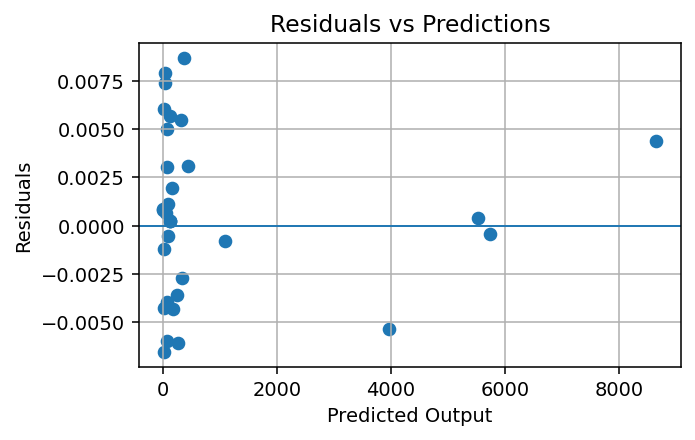

In [20]:
# The max_depth and subsample parameters are now included in the Bayesian Optimization search space.
# We will use the optimized values found in 'best_params' for the final model.

best_row = log_df.iloc[log_df["best_rmse_so_far"].idxmin()]
best_params = {k: float(best_row[k]) for k in space.keys()}
best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["max_depth"] = int(best_params["max_depth"]) # Ensure max_depth is an integer

print("Optimized hyperparameters (from BO):")
for k, v in best_params.items():
    print(f"  {k}: {v}")

final = GradientBoostingRegressor(
    n_estimators=best_params["n_estimators"],
    learning_rate=best_params["learning_rate"],
    max_depth=best_params["max_depth"], # Use the optimized max_depth
    subsample=best_params["subsample"], # Use the optimized subsample
    random_state=42
)
final_rmse = rmse_cv(final)
print("\nFinal (BO) 5-fold RMSE:", round(final_rmse, 3))

final.fit(X, y)
pred = final.predict(X)
resid = y - pred # Corrected: subtract predictions from actual target values (y)

plt.figure()
plt.scatter(pred, resid)
plt.axhline(0, linewidth=1)
plt.xlabel("Predicted Output"); plt.ylabel("Residuals") # Changed label for generality
plt.title("Residuals vs Predictions")
plt.show()

### Log review (each step)

In [21]:
try:
    import caas_jupyter_tools as cj
    subset_cols = ["iter","tag","rmse","best_rmse_so_far","mu","sigma","ei","exploit_contrib","explore_contrib"] + list(space.keys())
    log_view = log_df[subset_cols].round(4)
    cj.display_dataframe_to_user("BayesOpt_Step_Log", log_view)
except Exception:
    pass

log_df.head(25)

,iter,tag,rmse,best_rmse_so_far,mu,sigma,ei,exploit_contrib,explore_contrib,n_estimators,learning_rate,max_depth,subsample,min_samples_leaf
0,-9,Warm-up,1859.372395,1859.372395,NaN,NaN,NaN,NaN,NaN,433.0,0.150208,3.0,0.641052,15.0
1,-8,Warm-up,1771.144996,1771.144996,NaN,NaN,NaN,NaN,NaN,283.0,0.490574,7.0,0.584746,8.0
2,-7,Warm-up,1728.584244,1728.584244,NaN,NaN,NaN,NaN,NaN,239.0,0.367234,5.0,0.247742,9.0
3,-6,Warm-up,1834.682879,1728.584244,NaN,NaN,NaN,NaN,NaN,456.0,0.099421,3.0,0.625241,11.0
4,-5,Warm-up,1887.372993,1728.584244,NaN,NaN,NaN,NaN,NaN,399.0,0.426222,8.0,0.688819,15.0
5,-4,Warm-up,1689.036309,1689.036309,NaN,NaN,NaN,NaN,NaN,228.0,0.187276,3.0,0.434971,13.0
6,-3,Warm-up,1841.350822,1689.036309,NaN,NaN,NaN,NaN,NaN,101.0,0.222514,5.0,0.594948,9.0
7,-2,Warm-up,1830.193630,1689.036309,NaN,NaN,NaN,NaN,NaN,222.0,0.218912,9.0,0.955328,11.0
8,-1,Warm-up,1831.061554,1689.036309,NaN,NaN,NaN,NaN,NaN,393.0,0.066653,4.0,0.531861,17.0
9,0,Warm-up,1734.042480,1689.036309,NaN,NaN,NaN,NaN,NaN,188.0,0.246687,10.0,0.615588,13.0


# **Suggesting the Next X Data Point using Bayesian Optimization**

To find the next best x (4D coordinates) to sample the yield of a chemical process in a factory. The function is typically unimodal, with a single peak where yield is maximised.

Your goal is to find the optimal combination of chemical inputs that delivers the highest possible yield, using systematic exploration and optimisation methods. We will set up a separate Bayesian Optimization process. This process will:

Fit a Gaussian Process Regressor on the existing X (4D coordinates) and y (yield,). Generate a grid of candidate points across the 4D input space. Evaluate an Acquisition Function (like Upper Confidence Bound - UCB) for each candidate point. Identify the candidate point with the highest acquisition function value as the next suggested x for sampling.

In [22]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the 4D search space for combination of drugs
# The X values represent amounts of four compounds, typically normalized between [0, 1]
x_space = [(0, 1), (0, 1), (0, 1), (0, 1)] # Define the bounds for each of the four X features

d_x = X.shape[1] # Dimension of the X input space (should be 4 for the drug compounds)

# 2. Initialize and fit a Gaussian Process Regressor on the existing drug compound data
# We'll use the same kernel structure as for hyperparameter optimization, but applied to the X, y data
# Note: Normalizing y is crucial for GP performance
kernel_3d = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(d_x), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-2))
gpr_3d = GaussianProcessRegressor(kernel=kernel_3d, normalize_y=True, random_state=42, n_restarts_optimizer=3)

gpr_3d.fit(X, y)

# 3. Generate a grid of candidate points across the 4D input space
n_candidates_3d = 10000 # Number of candidate points for the 4D search space

# Create a uniform grid of candidates within the defined x_space
# For simplicity, we'll generate random candidates within the bounds [0,1] for all four features
candidates_3d = np.random.rand(n_candidates_3d, d_x)

# 4. Predict mean and standard deviation for these candidates
mu_3d, std_3d = gpr_3d.predict(candidates_3d, return_std=True)

# 5. Compute the Upper Confidence Bound (UCB) acquisition function
# We need to decide on a KAPPA for this 4D search. A higher KAPPA means more exploration.
KAPPA_3D = KAPPA # You can adjust this value to control exploration vs. exploitation for the 4D space

# Since we are trying to MAXIMIZE the (transformed) output (minimizing side effects),
# UCB is calculated as mu + KAPPA * std
ucb_acquisition = mu_3d + KAPPA_3D * std_3d

# 6. Identify the candidate point with the maximum UCB
best_ucb_idx = np.argmax(ucb_acquisition)
next_x_data_point = candidates_3d[best_ucb_idx]
predicted_y_at_next_x = mu_3d[best_ucb_idx]
predicted_std_at_next_x = std_3d[best_ucb_idx]

print(f"Suggested next X data point (4D coordinates): {next_x_data_point}")
print(f"Predicted Y at this point (mean): {predicted_y_at_next_x:.5e}")
print(f"Predicted uncertainty (std) at this point: {predicted_std_at_next_x:.5e}")
print(f"UCB value at this point: {ucb_acquisition[best_ucb_idx]:.5e}")

# For 4D data, direct 2D visualization is not appropriate for all features simultaneously.
# Instead of a scatter plot, we'll rely on the printed 4D coordinates.

Suggested next X data point (4D coordinates): [0.99607807 0.86430434 0.73951538 0.99692093]
Predicted Y at this point (mean): 7.37172e+03
Predicted uncertainty (std) at this point: 5.15253e+02
UCB value at this point: 7.50053e+03


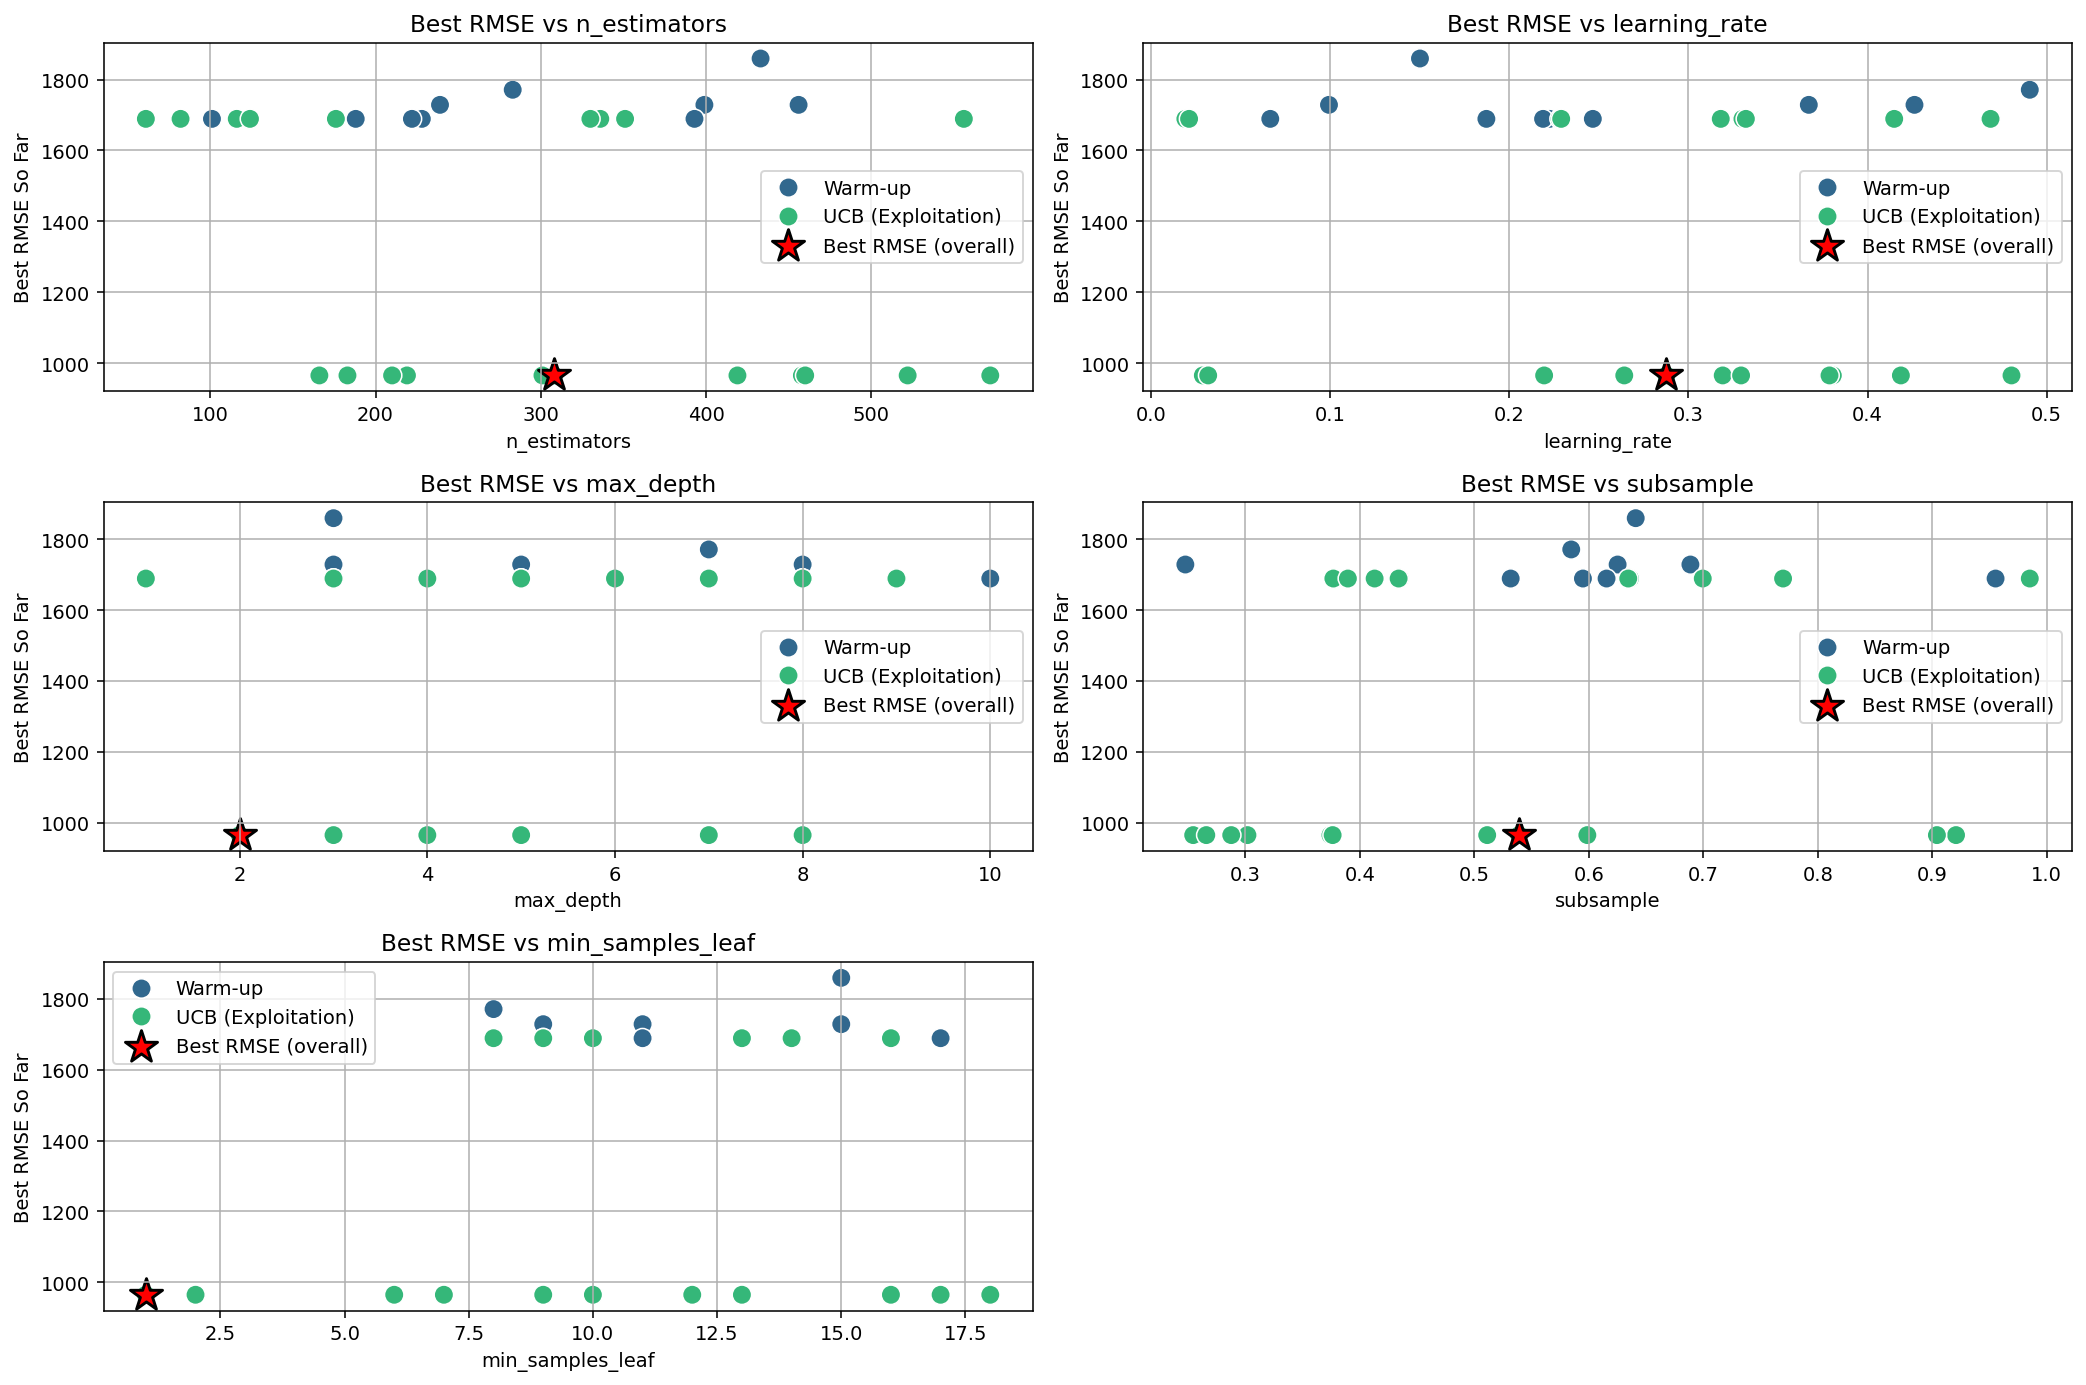

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

hyperparameters = list(space.keys())

plt.figure(figsize=(15, 10))
for i, hp_name in enumerate(hyperparameters):
    plt.subplot(3, 2, i + 1) # Arrange plots in a 2x2 grid
    sns.scatterplot(data=log_df, x=hp_name, y='best_rmse_so_far', hue='tag', palette='viridis', s=100)

    # Get the best RMSE and its corresponding row across all hyperparameters
    best_rmse_val_overall = log_df['best_rmse_so_far'].min()
    best_row = log_df[log_df['best_rmse_so_far'] == best_rmse_val_overall].iloc[0]

    # Highlight the best overall RMSE point for the current hyperparameter
    best_hp_value = best_row[hp_name]
    best_rmse_value = best_row['best_rmse_so_far']
    plt.scatter(best_hp_value, best_rmse_value, color='red', marker='*', s=300, edgecolor='black', linewidth=1.5, label='Best RMSE (overall)')

    plt.title(f'Best RMSE vs {hp_name}')
    plt.xlabel(hp_name)
    plt.ylabel('Best RMSE So Far')
    plt.grid(True)
    if hp_name in ['n_estimators', 'max_depth']:
        plt.ticklabel_format(useOffset=False, style='plain', axis='x') # Prevent scientific notation for integer axes
    plt.legend()

plt.tight_layout()
plt.show()

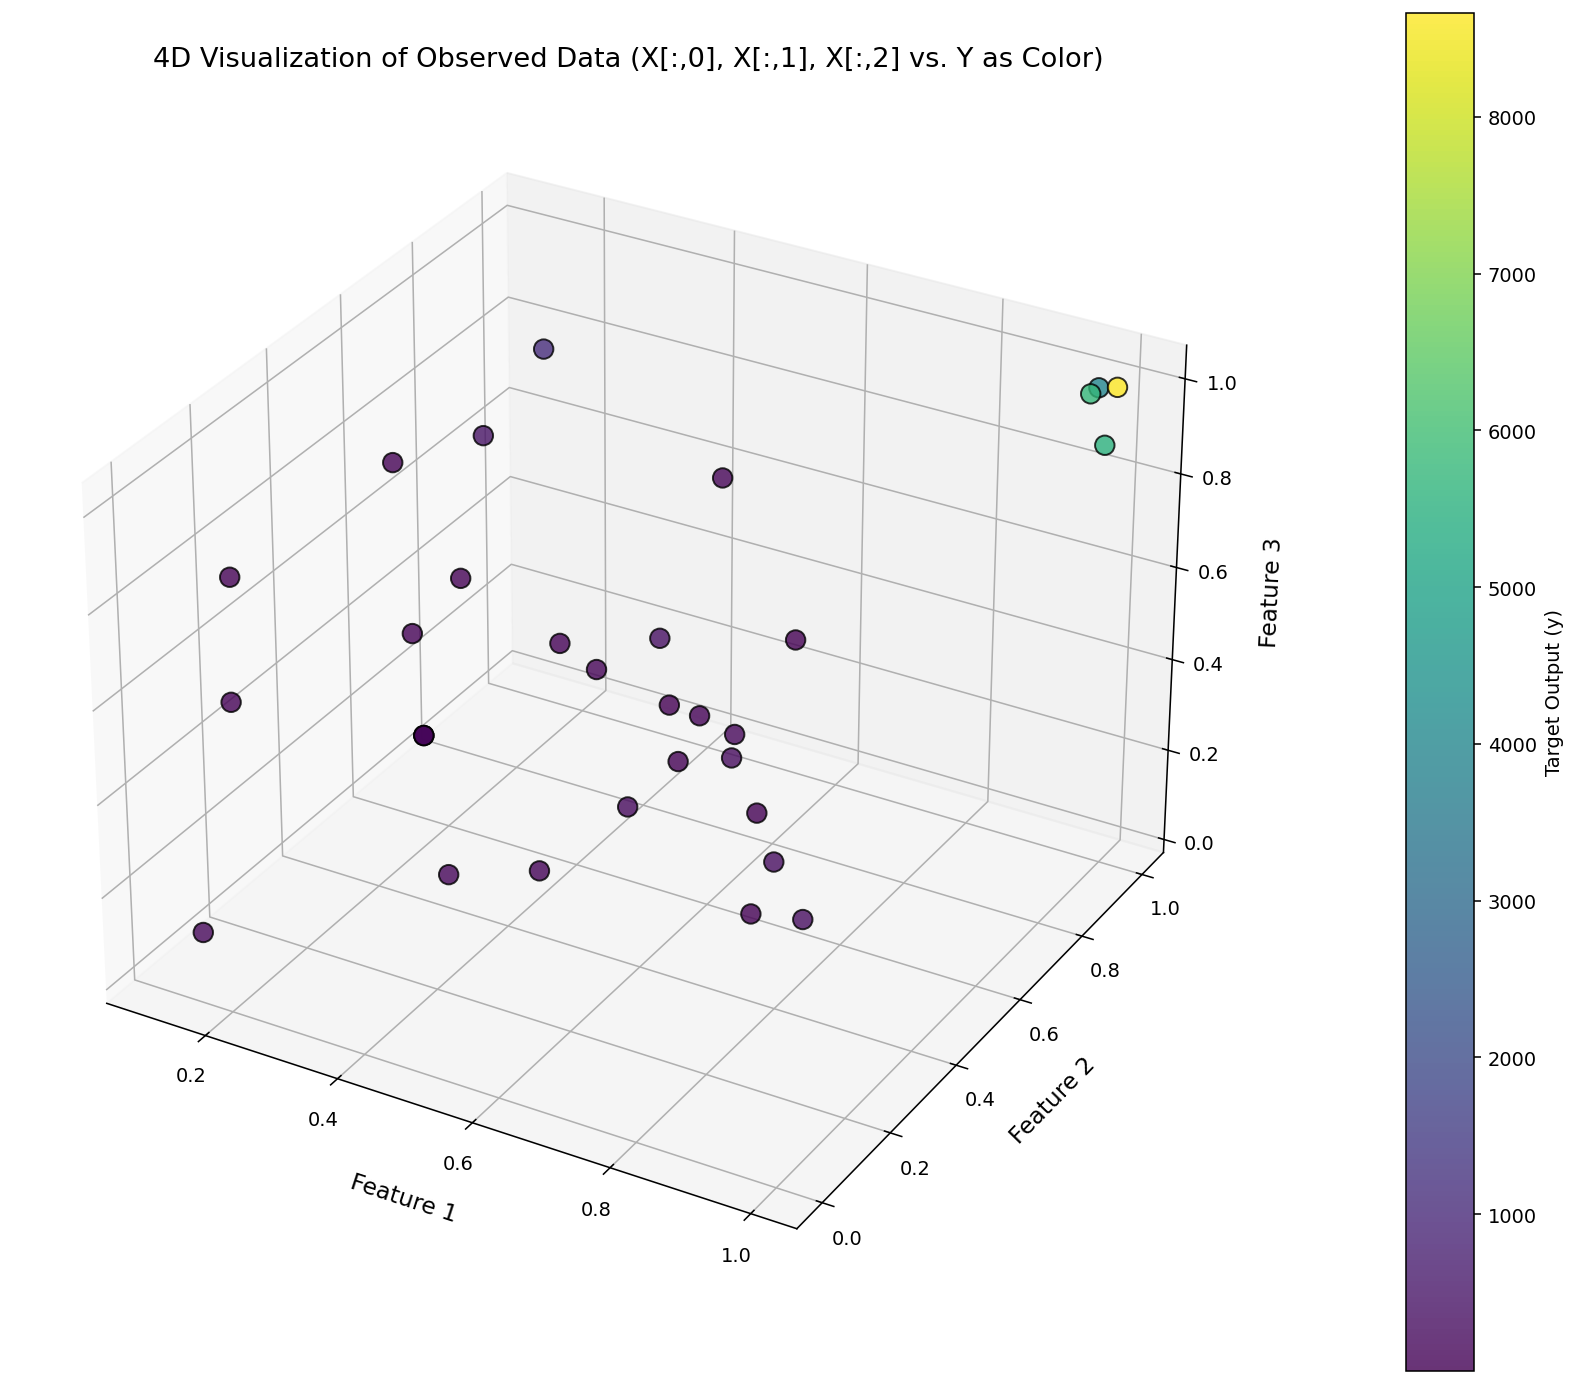

Displayed: 4D Scatter Plot of Observed Data


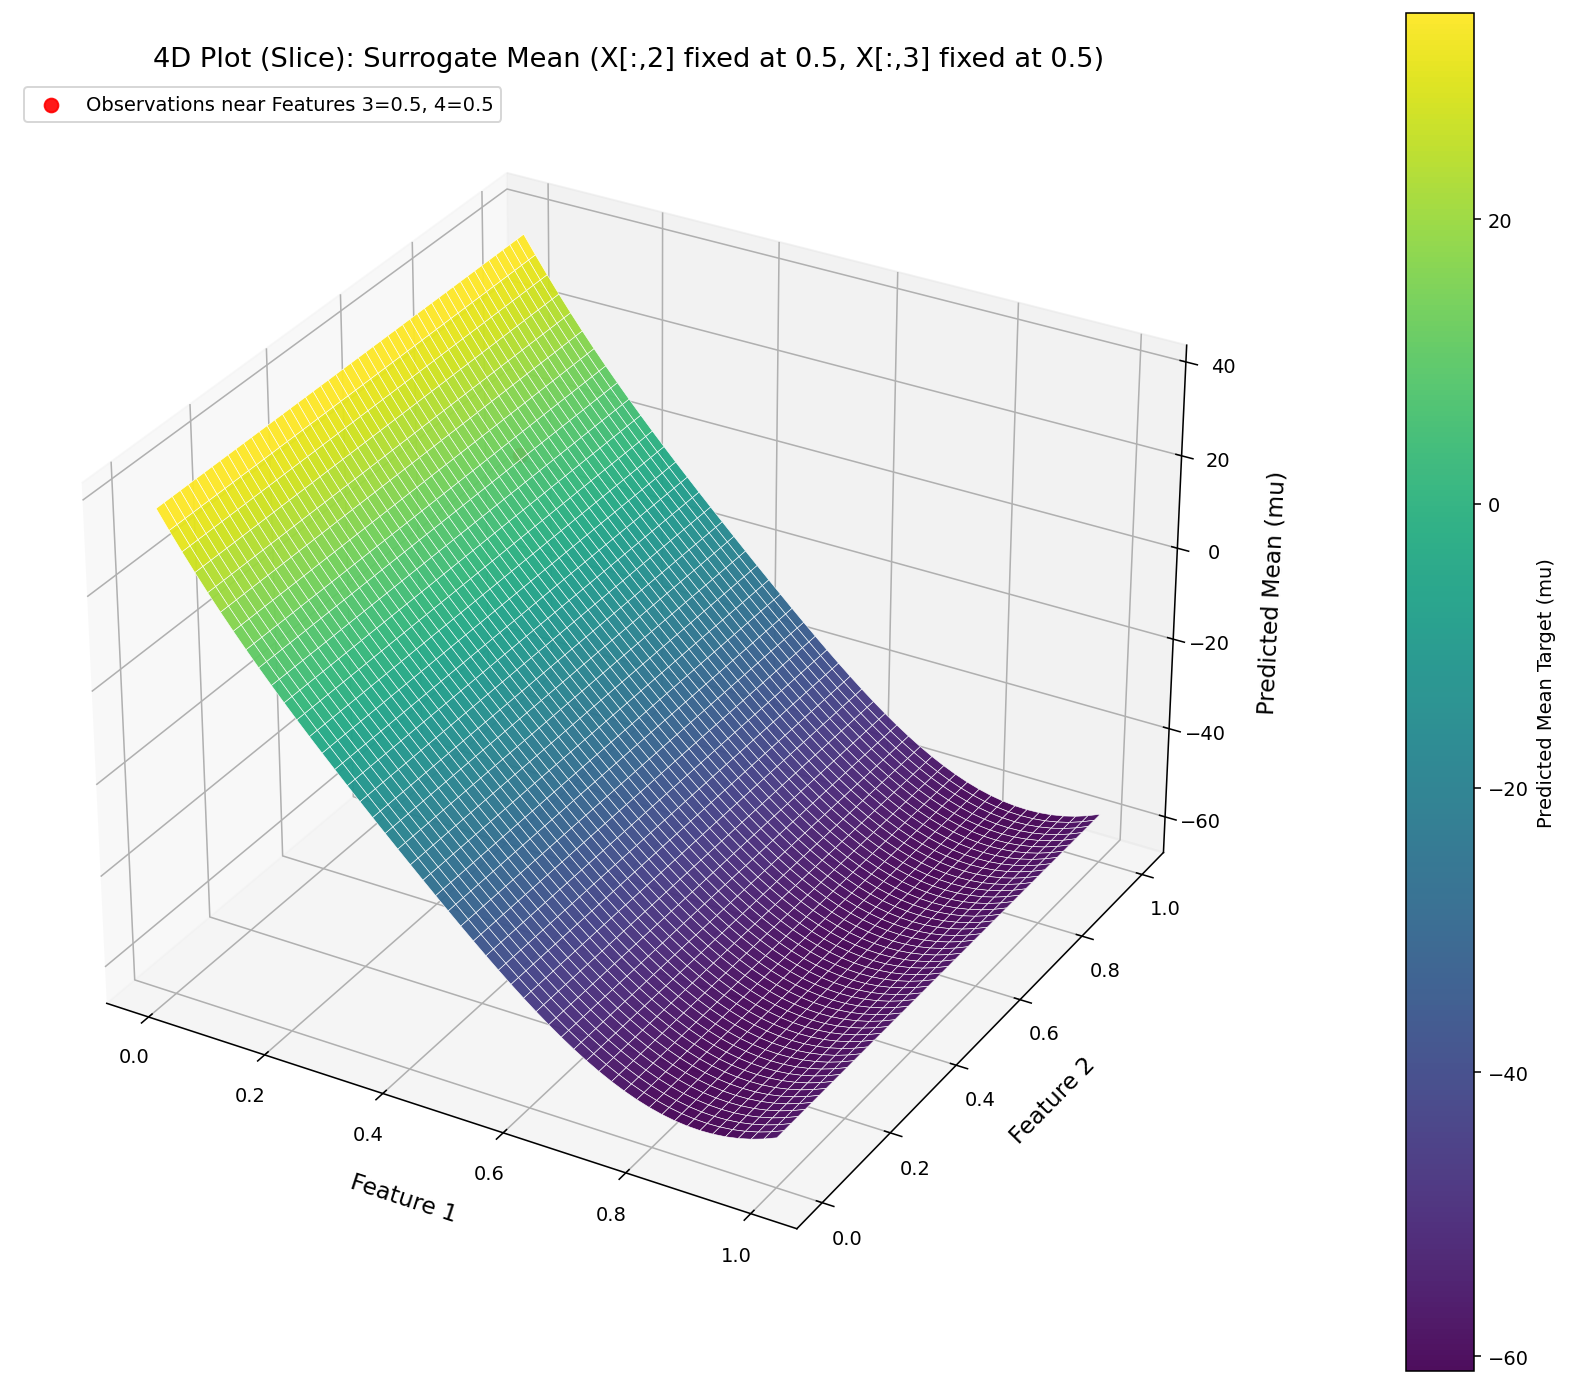

Displayed: 4D Slice Plot for Surrogate Mean (Features 3 fixed at 0.5, 4 fixed at 0.5)


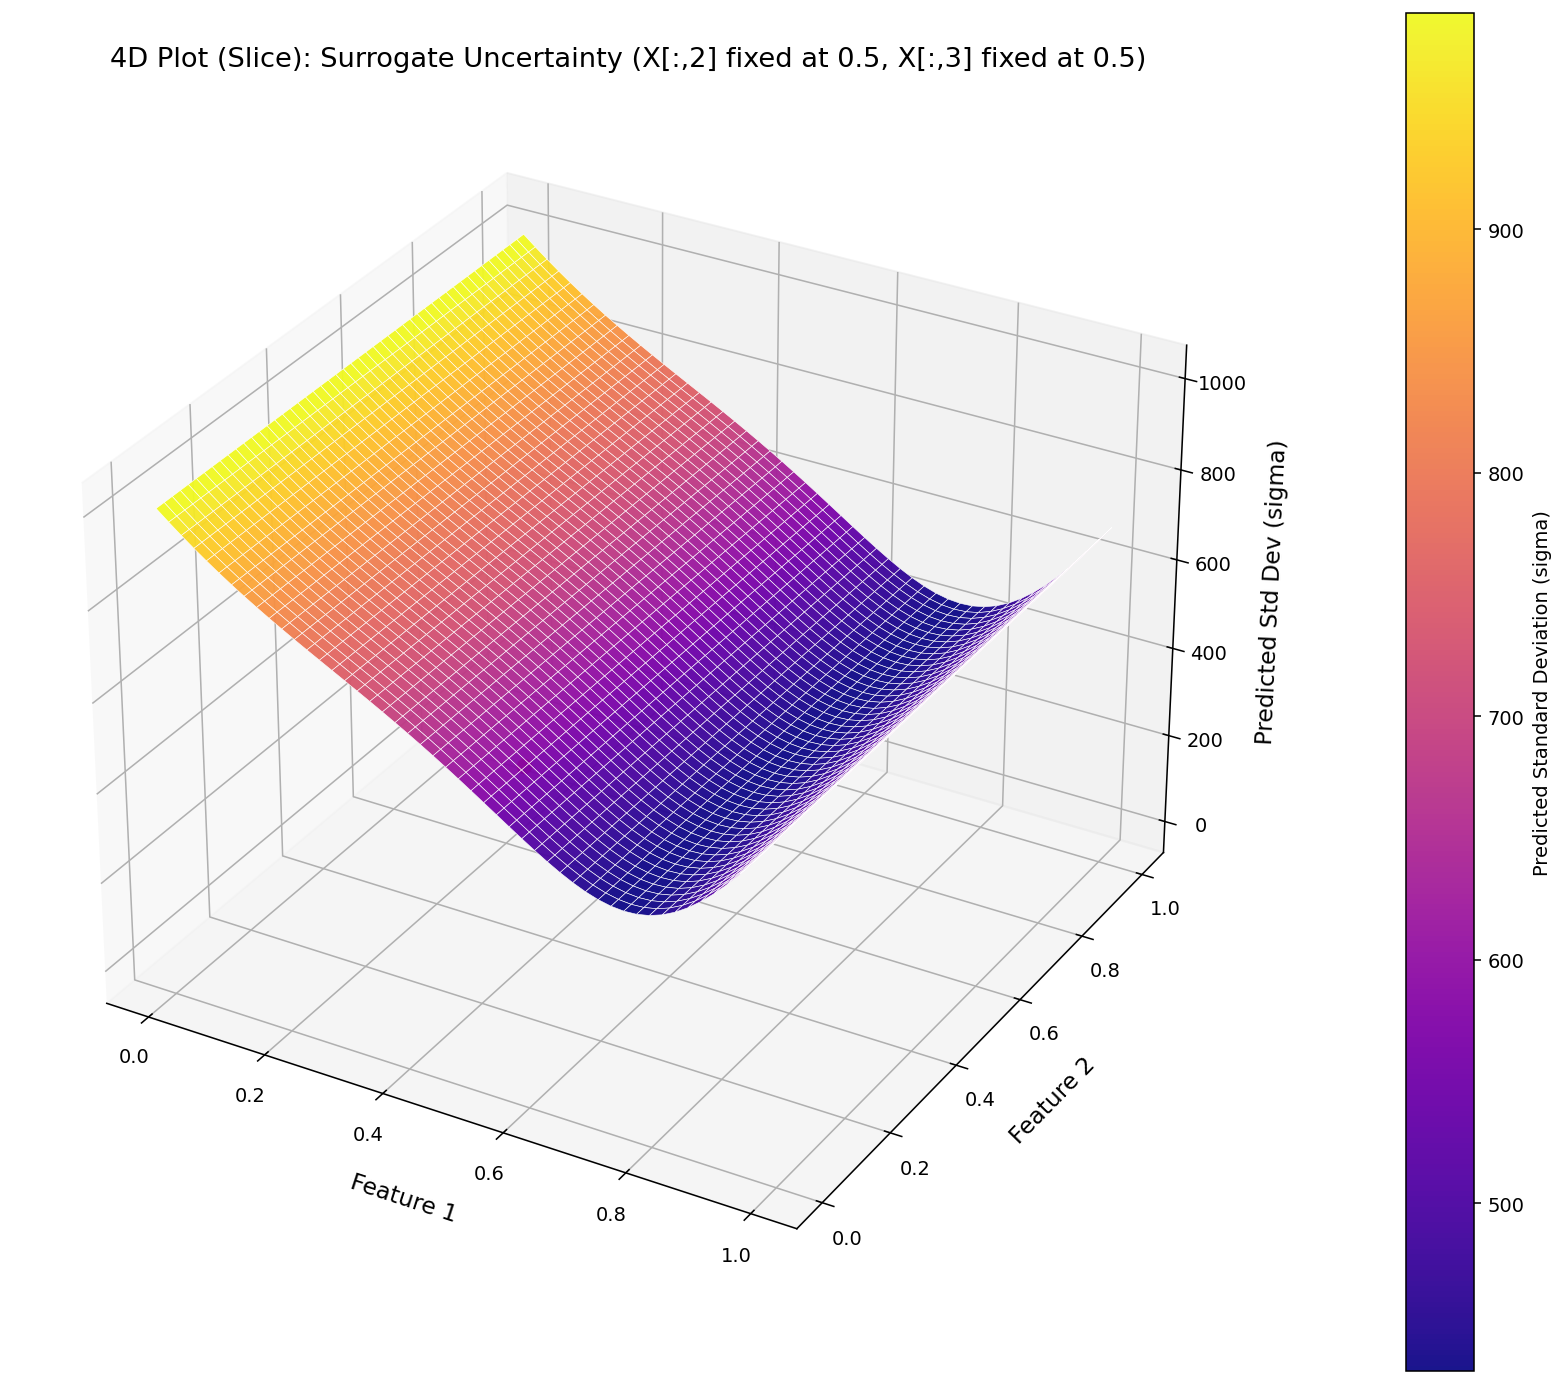

Displayed: 4D Slice Plot for Surrogate Uncertainty (Features 3 fixed at 0.5, 4 fixed at 0.5)


In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

resolution = 50 # Reduced resolution for faster plotting of slices

# The gpr_3d model was defined and fitted in cell 'qd_rPFSHpykn'
gp = gpr_3d

# Observed data
X_obs = X # Global variable X from the notebook state (3D input)
y_obs = y # Global variable y from the notebook state (1D output)

# ───────────────────────────────
# 1. 4D Plot: 3D Scatter Plot of Observations with Color representing Y
# ───────────────────────────────
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Create a colormap based on the range of y_obs values
scatter = ax.scatter(
    X_obs[:, 0], X_obs[:, 1], X_obs[:, 2],
    c=y_obs, # Color represents the 4th dimension (y_obs)
    cmap='viridis', # Choose a colormap
    s=100, # Marker size
    edgecolor='k', # Black edge for markers
    alpha=0.8
)

# Add a color bar
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Target Output (y)')

ax.set_title('4D Visualization of Observed Data (X[:,0], X[:,1], X[:,2] vs. Y as Color)', fontsize=14)
ax.set_xlabel('Feature 1', fontsize=12, labelpad=10)
ax.set_ylabel('Feature 2', fontsize=12, labelpad=10)
ax.set_zlabel('Feature 3', fontsize=12, labelpad=10)
ax.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.savefig('observed_data_4d.png', dpi=300, bbox_inches='tight') # Save the plot
plt.show()
print("Displayed: 4D Scatter Plot of Observed Data")

# ───────────────────────────────
# 2. 4D Plot (Slice): Surrogate Mean Surface by fixing Feature 3 and 4
#    This shows a 3D slice of the 4D surrogate function (2 inputs + 1 output)
# ───────────────────────────────
fig2 = plt.figure(figsize=(12, 10))
ax2 = fig2.add_subplot(111, projection='3d')

# Define ranges for the two features we will vary
x1_min, x1_max = 0, 1
x2_min, x2_max = 0, 1

# Create a grid for X[:,0] and X[:,1]
x1_grid = np.linspace(x1_min, x1_max, resolution)
x2_grid = np.linspace(x2_min, x2_max, resolution)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

# Fix Feature 3 (X[:,2]) at its mean or a chosen value (e.g., 0.5)
fixed_x3_value = 0.5 # Can also use np.mean(X_obs[:, 2])
fixed_x4_value = 0.5 # Fix Feature 4 (X[:,3]) at a chosen value

# Create the 4D input grid for prediction for this slice
# Each point will be [X1_val, X2_val, fixed_x3_value, fixed_x4_value]
X_slice_grid = np.column_stack([X1.ravel(), X2.ravel(), np.full(X1.size, fixed_x3_value), np.full(X1.size, fixed_x4_value)])

# Predict mean and std for this slice from the GPR
mu_slice, std_slice = gp.predict(X_slice_grid, return_std=True)
Mu_slice_surface = mu_slice.reshape(resolution, resolution)
Std_slice_surface = std_slice.reshape(resolution, resolution)

# Plot the surrogate mean surface
surf_mean = ax2.plot_surface(
    X1, X2, Mu_slice_surface,
    cmap='viridis',
    edgecolor='white',
    linewidth=0.3,
    alpha=0.95
)

# Scatter the observed points that are close to the fixed_x3_value and fixed_x4_value
# (Optional: to show how observations relate to the slice)
tolerance = 0.1 # Define a tolerance for "close"
close_points_mask = ((X_obs[:, 2] >= fixed_x3_value - tolerance) & (X_obs[:, 2] <= fixed_x3_value + tolerance)) & \
                    ((X_obs[:, 3] >= fixed_x4_value - tolerance) & (X_obs[:, 3] <= fixed_x4_value + tolerance))
ax2.scatter(
    X_obs[close_points_mask, 0], X_obs[close_points_mask, 1], y_obs[close_points_mask],
    color='red', s=50, zorder=5, label=f'Observations near Features 3={fixed_x3_value}, 4={fixed_x4_value}', alpha=0.9
)


# Add a color bar for the surface
cbar_mean = fig2.colorbar(surf_mean, ax=ax2, pad=0.1)
cbar_mean.set_label('Predicted Mean Target (mu)')

ax2.set_title(f'4D Plot (Slice): Surrogate Mean (X[:,2] fixed at {fixed_x3_value}, X[:,3] fixed at {fixed_x4_value})', fontsize=14)
ax2.set_xlabel('Feature 1', fontsize=12, labelpad=10)
ax2.set_ylabel('Feature 2', fontsize=12, labelpad=10)
ax2.set_zlabel('Predicted Mean (mu)', fontsize=12, labelpad=10)
ax2.tick_params(axis='both', labelsize=10)
ax2.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('surrogate_mean_slice_4d.png', dpi=300, bbox_inches='tight') # Save the plot
plt.show()
print(f"Displayed: 4D Slice Plot for Surrogate Mean (Features 3 fixed at {fixed_x3_value}, 4 fixed at {fixed_x4_value})")

# ───────────────────────────────
# 3. 4D Plot (Slice): Surrogate Uncertainty Surface by fixing Features 3 and 4
# ───────────────────────────────
fig3 = plt.figure(figsize=(12, 10))
ax3 = fig3.add_subplot(111, projection='3d')

# Plot the surrogate uncertainty surface
surf_std = ax3.plot_surface(
    X1, X2, Std_slice_surface,
    cmap='plasma', # Good for uncertainty
    edgecolor='white',
    linewidth=0.3,
    alpha=0.95
)

# Scatter the observed points that are close to the fixed_x3_value and fixed_x4_value (optional)
ax3.scatter(
    X_obs[close_points_mask, 0], X_obs[close_points_mask, 1], np.zeros_like(y_obs[close_points_mask]), # Project to Z=0 for context
    color='red', s=50, zorder=5, label=f'Observations near Features 3={fixed_x3_value}, 4={fixed_x4_value}', alpha=0.9
)

# Add a color bar for the uncertainty surface
cbar_std = fig3.colorbar(surf_std, ax=ax3, pad=0.1)
cbar_std.set_label('Predicted Standard Deviation (sigma)')

ax3.set_title(f'4D Plot (Slice): Surrogate Uncertainty (X[:,2] fixed at {fixed_x3_value}, X[:,3] fixed at {fixed_x4_value})', fontsize=14)
ax3.set_xlabel('Feature 1', fontsize=12, labelpad=10)
ax3.set_ylabel('Feature 2', fontsize=12, labelpad=10)
ax3.set_zlabel('Predicted Std Dev (sigma)', fontsize=12, labelpad=10)
ax3.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.savefig('surrogate_uncertainty_slice_4d.png', dpi=300, bbox_inches='tight') # Save the plot
plt.show()
print(f"Displayed: 4D Slice Plot for Surrogate Uncertainty (Features 3 fixed at {fixed_x3_value}, 4 fixed at {fixed_x4_value})")

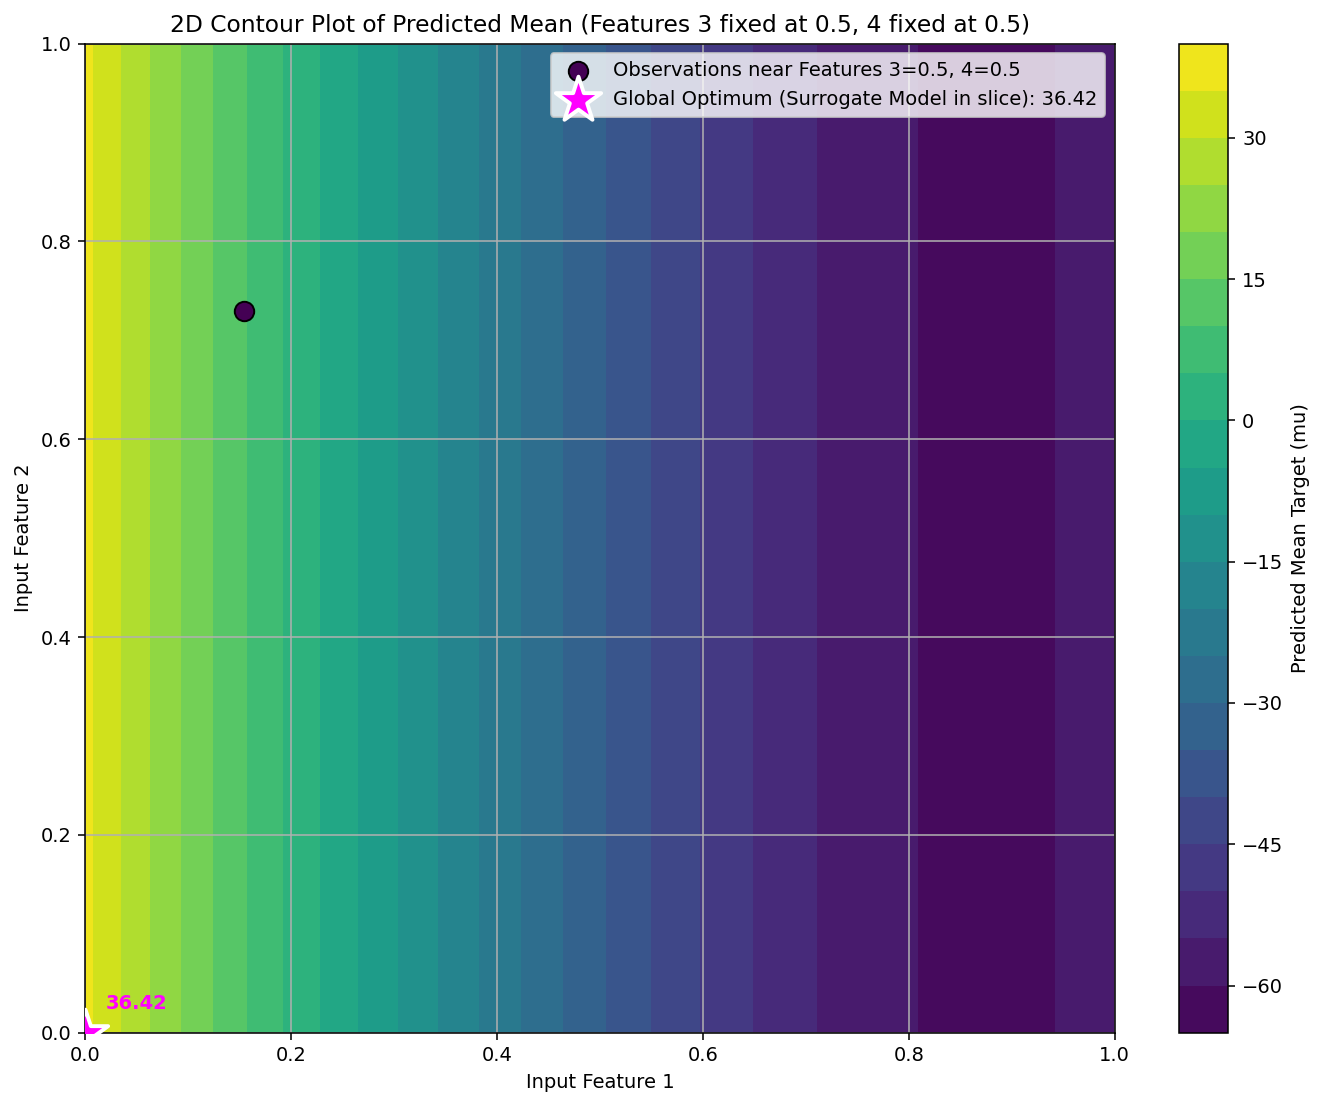

Saved: gp_surrogate_mean_contour_4d_input_slice.png

Global Optimum within slice (X1, X2, fixed X3, fixed X4): [0.  0.  0.5 0.5]
Predicted Mean Target (yield) at this point: 3.64229e+01


In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming gpr_3d, X, y, next_x_data_point, predicted_y_at_next_x are available from previous cells.

# Define parameters for the 2D slice visualization (fixing Feature 3 and Feature 4)
fixed_x3_value = 0.5
fixed_x4_value = 0.5
resolution = 50 # Resolution for the grid of the 2D slice

# Create a grid for X[:,0] and X[:,1]
x1_grid = np.linspace(0, 1, resolution)
x2_grid = np.linspace(0, 1, resolution)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

# Create the 4D input grid for prediction for this slice
# Each point will be [X1_val, X2_val, fixed_x3_value, fixed_x4_value]
X_slice_grid = np.column_stack([X1.ravel(), X2.ravel(), np.full(X1.size, fixed_x3_value), np.full(X1.size, fixed_x4_value)])

# Predict mean from the fitted GPR (gpr_3d)
mu_slice, _ = gpr_3d.predict(X_slice_grid, return_std=True)
Mu_slice_surface = mu_slice.reshape(resolution, resolution)

fig, ax = plt.subplots(figsize=(10, 8)) # Get fig and ax objects
contour = ax.contourf(X1, X2, Mu_slice_surface, levels=20, cmap='viridis')
fig.colorbar(contour, ax=ax, label='Predicted Mean Target (mu)')

# Scatter the observed points that are close to the fixed_x3_value and fixed_x4_value
tolerance = 0.1 # Define a tolerance for "close"
close_points_mask = ((X[:, 2] >= fixed_x3_value - tolerance) & (X[:, 2] <= fixed_x3_value + tolerance)) & \
                    ((X[:, 3] >= fixed_x4_value - tolerance) & (X[:, 3] <= fixed_x4_value + tolerance))
ax.scatter(
    X[close_points_mask, 0], X[close_points_mask, 1], c=y[close_points_mask],
    cmap='viridis', s=100, edgecolors='k', label=f'Observations near Features 3={fixed_x3_value}, 4={fixed_x4_value}'
)

# Mark the suggested next sample point (if it falls within this slice)
# Check both fixed features for proximity
if np.isclose(next_x_data_point[2], fixed_x3_value, atol=tolerance) and \
   np.isclose(next_x_data_point[3], fixed_x4_value, atol=tolerance):
    ax.scatter(next_x_data_point[0], next_x_data_point[1],
                color='red', marker='X', s=200, label='Suggested Next Sample Point', zorder=5)

# Find the global maximum of Mu_slice_surface (as we are maximizing the transformed output)
# This is the global optimum *within this specific 2D slice* (for the two varying features)
max_mu_slice_idx = np.argmax(Mu_slice_surface)
# Get the 4D coordinates of this point within the slice
max_mu_slice_coords_flattened = X_slice_grid[max_mu_slice_idx]
max_mu_value_in_slice = Mu_slice_surface.max()

ax.scatter(
    max_mu_slice_coords_flattened[0], max_mu_slice_coords_flattened[1],
    color='magenta', marker='*', s=600, zorder=10, edgecolor='white', linewidth=2,
    label=f'Global Optimum (Surrogate Model in slice): {max_mu_value_in_slice:.2f}'
)

# Add text annotation for clarity
ax.text(max_mu_slice_coords_flattened[0] + 0.02, max_mu_slice_coords_flattened[1] + 0.02,
         f'{max_mu_value_in_slice:.2f}', color='magenta', fontsize=10, ha='left', va='bottom', weight='bold')

ax.set_title(f'2D Contour Plot of Predicted Mean (Features 3 fixed at {fixed_x3_value}, 4 fixed at {fixed_x4_value})')
ax.set_xlabel('Input Feature 1')
ax.set_ylabel('Input Feature 2')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('gp_surrogate_mean_contour_4d_input_slice.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: gp_surrogate_mean_contour_4d_input_slice.png")
print(f"\nGlobal Optimum within slice (X1, X2, fixed X3, fixed X4): {max_mu_slice_coords_flattened}")
print(f"Predicted Mean Target (yield) at this point: {max_mu_value_in_slice:.5e}")

In [29]:
import numpy as np

# --- 1. Global Maximum identified from Observed Data (y) ---
max_y_observed = np.max(y)
max_y_observed_idx = np.argmax(y)
max_X_observed = X[max_y_observed_idx]

print(f"\nObserved Global Maximum 'y' value: {max_y_observed:.5e}")
print(f"Corresponding 'X' values (Index {max_y_observed_idx}): {max_X_observed}")

# --- 2. Predicted Global Maximum (based on Surrogate Model gpr_3d) ---
# The gpr_3d model was already fitted in cell '4HScECjpuxOK' on X and y
# We will use the 'mu_3d' array which contains the predicted mean 'y' values for 'candidates_3d'

# Find the index of the maximum predicted mean 'y' value among all candidates
predicted_global_max_idx = np.argmax(mu_3d)
predicted_global_max_y = mu_3d[predicted_global_max_idx]
predicted_global_max_X = candidates_3d[predicted_global_max_idx]

# Get the uncertainty (standard deviation) at this predicted global maximum point
predicted_global_max_std = std_3d[predicted_global_max_idx]

print(f"\nPredicted Global Maximum 'y' value (from surrogate mean): {predicted_global_max_y:.5e}")
print(f"Corresponding 'X' values: {predicted_global_max_X}")
print(f"Uncertainty (std) at this predicted point: {predicted_global_max_std:.5e}")


Observed Global Maximum 'y' value: 8.66241e+03
Corresponding 'X' values (Index 20): [0.999999 0.999999 0.999999 0.999999]

Predicted Global Maximum 'y' value (from surrogate mean): 7.38511e+03
Corresponding 'X' values: [0.95576444 0.37290324 0.8919065  0.98336782]
Uncertainty (std) at this predicted point: 2.76003e+02
